Kaarina Mattika, CS87A, Section 1758
https://github.com/kmattika/cs82a-portfolio

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

Step One

In [2]:
df_storeorders = pd.read_csv(r'C:\Users\kamat\OneDrive\Desktop\CS82A\store_orders.csv')
df_storecustomers = pd.read_csv(r'C:\Users\kamat\OneDrive\Desktop\CS82A\store_customers.csv')

In [3]:
con = sqlite3.connect("store.db")
df_storeorders.to_sql("orders", con, if_exists="replace", index=False)
df_storecustomers.to_sql("customers", con, if_exists="replace", index=False)

40

In [4]:
pd.read_sql("SELECT name FROM sqlite_master", con)

,name
0,orders
1,customers


Step Two

In [5]:
pd.read_sql("SELECT * FROM orders LIMIT 5", con)

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


Step Three

In [6]:
query = '''
    SELECT order_id, customer_id, product, category, amount, order_date
    FROM orders
    WHERE amount > 100
    ORDER BY amount DESC
'''

pd.read_sql(query, con)

,order_id,customer_id,product,category,amount,order_date
0,5153,20,dock,electronics,499.00,2026-05-25
1,5140,30,headset,electronics,295.36,2026-05-26
2,5047,901,headset,electronics,293.79,2026-05-15
3,5150,903,monitor,electronics,293.35,2026-06-06
4,5014,6,monitor,electronics,287.83,2026-05-22
...,...,...,...,...,...,...
79,5107,38,shelf,furniture,110.31,2026-05-17
80,5046,13,shelf,furniture,108.47,2026-05-28
81,5009,14,chair,furniture,107.20,2026-05-24
82,5007,36,dock,electronics,103.77,2026-05-21


Step Four

In [7]:
query = '''

SELECT category, COUNT(*) AS n, AVG(amount) AS avg_amount
FROM orders
GROUP BY category
ORDER BY avg_amount DESC

'''
pd.read_sql(query, con)

,category,n,avg_amount
0,electronics,60,190.569500
1,furniture,46,146.251522
2,office,51,30.132549
3,snacks,43,14.619767


The 'electronics' category earns the most per order.

Step Eight

What is the best performing product in the electronics category?

In [8]:
query = '''

SELECT product, COUNT(*) AS n, AVG(amount) AS avg_amount
FROM orders
WHERE category = 'electronics'
GROUP BY product
ORDER BY avg_amount DESC

'''
pd.read_sql(query, con)

,product,n,avg_amount
0,headset,23,213.143478
1,monitor,17,186.748824
2,dock,20,167.857000


Here, we can see that the best performing product by average profit is the headset, as it ships more units and has a higher average sale quantity.

Step Five

In [9]:
query = '''

SELECT o.amount, c.city
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.city
ORDER BY amount DESC

'''
pd.read_sql(query, con)

,amount,city
0,181.41,Torrance
1,116.25,Venice
2,107.20,Inglewood
3,51.86,Santa Monica
4,19.72,Culver City
5,14.09,Los Angeles


Step Six

As noted in the data dictionary, five orders reference customer_ids that do not exist in the customers table. During the join process, these rows are dropped because we joined using the customer_id column as join key. Thus, those five rows are omitted following the table join.

Step Seven

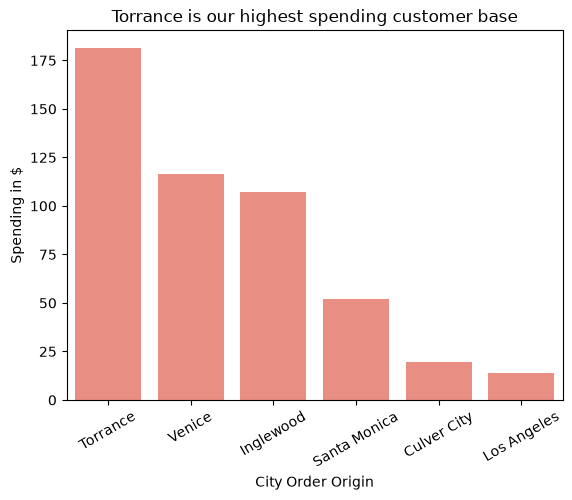

In [10]:
df_city_spending = pd.read_sql(query, con)

sns.barplot(
    data=df_city_spending,
    x='city',
    y='amount',
    color='salmon'
)

plt.title('Torrance is our highest spending customer base')
plt.xlabel('City Order Origin')
plt.ylabel('Spending in $')
plt.xticks(rotation=30)
plt.show()

Step Nine

Given that this database contains the PII of our customers, we would want to redact or anonymize the 'name' column found in the customers table. Statutory compliance with the California Consumer Privacy Act in our database is limited to just the real names of customers. We would also want to keep the original, non-compliant data in a hardened digital environment to prevent an attacker from breaching our security and leaking or ransoming our customer data, which could lead to penalties. 